---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** __장다예__ &nbsp; **학번:** ____20251281____ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. cancer.xlsx의 Data 시트 불러오기
df = pd.read_excel('cancer.xlsx', sheet_name='Data')
df.head()

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Endpoint,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,cancer_4298,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Weakly Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
1,cancer_4297,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
2,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Top dose,15,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
3,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Level of evidence of carcinogenic activity,Clear evidence,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
4,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026


In [39]:
# 데이터 내 존재하는 종(Species)의 분포 확인
df['Species'].value_counts()

Species
Mouse      3286
Rat        2905
Hamster      20
Name: count, dtype: int64

In [40]:
# Mouse 실험 결과+Chemical만 선택
df_m = df[(df['Species'] == 'Mouse') & (df['Mixture'] == 'Chemical')].copy()
df_m.head()

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Endpoint,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,cancer_4298,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Weakly Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
1,cancer_4297,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
4,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
5,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Level of evidence of carcinogenic activity,Inadequate experiment,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
6,cancer_3381,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026


In [41]:
# 마우스 데이터 내에 존재하는 Endpoint 종류 및 빈도 확인
df_m['Endpoint'].value_counts()

Endpoint
Top dose                                      1100
Level of evidence of carcinogenic activity    1098
Micronucleus                                   612
POLY-3 lowest dose                             321
Comet assay                                     25
Name: count, dtype: int64

In [42]:
#'Level of evidence of carcinogenic activity(발암성 평가 결과)'를 가진 데이터 추출
df_evi = df_m[df_m['Endpoint'] == 'Level of evidence of carcinogenic activity'].copy()

# 불확실한 결과(Equivocal, Inadequate, Not tested 등) 제거
valid_responses = ['Clear evidence', 'Some evidence', 'No evidence']
df_evi = df_evi[df_evi['Response'].isin(valid_responses)].copy()
df_evi.shape

(897, 28)

In [43]:
# 필터링된 최종 발암성 응답 값들의 분포 확인
df_evi['Response'].value_counts()

Response
No evidence       516
Clear evidence    320
Some evidence      61
Name: count, dtype: int64

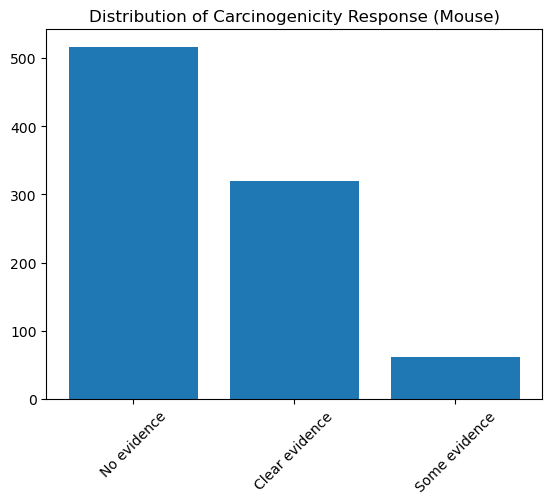

In [44]:
# 응답(Response) 값 분포 시각화
import matplotlib.pyplot as plt
evi_value = df_evi['Response'].value_counts()
plt.bar(evi_value.index, evi_value)
plt.xticks(rotation=45)
plt.title('Distribution of Carcinogenicity Response (Mouse)')
plt.show()

In [45]:
# 데이터 칼럼 확인
df_evi.columns

Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Mixture', 'Species', 'Sex', 'Strain', 'Route', 'Level_of_Evidence',
       'Tissue', 'Location', 'Lesion', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name',
       'Synonyms', 'URL_CompTox', 'URL_CEBS'],
      dtype='str')

In [46]:
# 타겟 변수 이진 라벨링 ('Clear evidence', 'Some evidence'(발암성 있음) = 1, 'No evidence'(발암성 없음) = 0)
df_evi['label'] = 0
df_evi.loc[df_evi['Response'].isin(['Clear evidence', 'Some evidence']),'label'] = 1

df_evi['label'].value_counts()

label
0    516
1    381
Name: count, dtype: int64

In [47]:
# 각 화학 물질(SMILES)이 서로 다른 라벨을 중복으로 가지고 있는지 종류 개수(nunique) 확인
label_count = df_evi.groupby('SMILES')['label'].nunique()
label_count.head()

SMILES
*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|                        1
BrC(Br)Br                                                      1
BrC(Br)C#N                                                     1
BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2Br)C(Br)=C1Br    1
BrCC(Br)(CCC#N)C#N                                             1
Name: label, dtype: int64

In [48]:
# 라벨 종류가 2개 이상인 오류 데이터(하나의 물질이 0과 1 라벨을 동시에 가짐)의 총 개수 확인
len(label_count[label_count > 1])

51

In [49]:
# 1. 라벨 종류가 2개 이상인 오류 물질의 SMILES 목록 추출
conflict_smiles = label_count[label_count > 1].index

# 2. 원본 데이터셋에서 해당 오류 물질을 포함하는 모든 데이터 행을 필터링
df_conflict = df_evi[df_evi['SMILES'].isin(conflict_smiles)]

df_conflict.shape

(113, 29)

In [72]:
# 라벨 모순이 발생한 원인을 분석하기 위해 주요 변수(SMILES, 성별, 라벨) 위주로 상위 20개 데이터 확인
df_conflict[['SMILES','Sex','label']].head(20)[['SMILES','Sex','label']].head(20)

,SMILES,Sex,label
24,CC(=O)OCC1=CC=CC=C1,Male,1
27,CC(=O)OCC1=CC=CC=C1,Female,1
33,CC(=O)OCC1=CC=CC=C1,Female,0
37,CC(=O)OCC1=CC=CC=C1,Male,0
57,NC1=CC(N)=C(Cl)C=C1,Male,0
61,NC1=CC(N)=C(Cl)C=C1,Female,1
529,CCCCC(CC)COP(=O)(OCC(CC)CCCC)OCC(CC)CCCC,Female,1
531,CCCCC(CC)COP(=O)(OCC(CC)CCCC)OCC(CC)CCCC,Male,0
687,"C*.O=C=NC1=CC(=CC=C1)N=C=O |c:6,8,t:4,lp:2:2,4...",Female,1
689,"C*.O=C=NC1=CC(=CC=C1)N=C=O |c:6,8,t:4,lp:2:2,4...",Male,0


In [51]:
smiles = 'CC(=O)OCC1=CC=CC=C1'

df_evi[df_evi['SMILES'] == smiles][['SMILES','Sex','Route','label']]

,SMILES,Sex,Route,label
24,CC(=O)OCC1=CC=CC=C1,Male,Gavage,1
27,CC(=O)OCC1=CC=CC=C1,Female,Gavage,1
33,CC(=O)OCC1=CC=CC=C1,Female,Dosed feed,0
37,CC(=O)OCC1=CC=CC=C1,Male,Dosed feed,0


In [73]:
# Route(투여 경로) 분포
df_evi['Route'].value_counts()

Route
Dosed feed                   334
Gavage                       218
Inhalation                   109
Dermal                        39
Dosed drinking water          35
Intraperitoneal injection     11
Gavage; Dosed feed             4
Transplacental                 3
Dosed feed; Dermal             2
Intravaginal                   1
Name: count, dtype: int64

### 라벨 모순(conflicting label) 해결

같은 화합물이 성별/투여경로 등에 따라 여러 행으로 기록되어 있어서,
화합물 1개에 라벨이 0과 1이 섞여 있는 경우가 51건 있었음. (11번 셀)

이전 버전에서는 `Route == 'Dosed feed'`인 행만 남기는 방식은 **분석 대상 화합물 수가 897건 → 334건으로 임의로 줄어드는 문제**가 있었고, 그 안에서도 여전히 23건은 모순이 남아 있어 결국 `drop_duplicates`로 그냥 먼저 나온 값을 채택해버리는 한계가 있었음.

화합물(SMILES) 단위로 모든 실험 결과를 모아 다수결(majority vote)로 대표 라벨을 정합니다. 찬성/반대가 완전히 동률인 경우에만 진짜 모순으로 보고 해당 화합물을 제외했음.


In [74]:
# [라벨 모순 해결 함수 정의] 다수결 원칙 적용
def resolve_label(labels):
    counts = labels.value_counts() # 각 라벨의 빈도수 계산
    
    if len(counts) == 1:
        return counts.index[0]     # 라벨이 1종류뿐이면 해당 라벨 그대로 반환
    if counts.iloc[0] == counts.iloc[1]:
        return np.nan              # 1과 0의 빈도수가 동률이면 결측치(NaN)로 처리하여 추후 제외
    return counts.index[0]         # 빈도수가 더 높은(다수결) 라벨 반환

# 각 화학 물질(SMILES)별로 위 다수결 함수를 적용하여 라벨 통합
resolved_label = df_evi.groupby('SMILES')['label'].apply(resolve_label)

# 모순 해결 결과 확인
n_total = len(resolved_label)
n_tie = int(resolved_label.isna().sum()) # NaN(동률)의 개수 파악
print(f"전체 화합물(SMILES) 수: {n_total}")
print(f"동률이라 제외되는 화합물 수: {n_tie}")

# 동률로 인해 결측치(NaN)로 처리된 화합물 데이터 최종 제거
resolved_label = resolved_label.dropna()

전체 화합물(SMILES) 수: 446
동률이라 제외되는 화합물 수: 49


In [75]:
# 1. 중복된 SMILES 행을 제거하고, 인덱스를 'SMILES'로 설정하여 정렬 준비
df_route = df_evi.drop_duplicates(subset='SMILES').set_index('SMILES')

# 2. 앞서 모순을 해결하고 살아남은 화합물 목록(resolved_label의 인덱스)만 필터링 후 인덱스 초기화
df_route = df_route.loc[resolved_label.index].reset_index()

# 3. 데이터프레임의 라벨 변수를 앞서 다수결로 정제한 최종 라벨 값으로 교체
df_route['label'] = resolved_label.values

# 최종 정제된 데이터셋의 행/열 개수 출력
print(df_route.shape)

# 최종 데이터셋의 클래스(0: 발암성 없음, 1: 발암성 있음)별 빈도수 확인 (데이터 불균형 파악)
df_route['label'].value_counts()

(397, 29)


label
0.0    238
1.0    159
Name: count, dtype: int64

In [55]:
df_route.to_csv('cancer_route.csv', index=False)

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem

In [77]:
cancer_data = df_route.copy()

# 데이터셋의 크기(Shape) 확인
print(cancer_data.shape)
cancer_data.head()

(397, 29)


,SMILES,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,...,Endpoint,Response,Response_Unit,Reference,URL,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS,label
0,"*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|",cancer_6589,In Vivo,NaN,Divinylbenzene-HP,Divinylbenzene,1321-74-0,DTXSID2025216,NaN,Chemical,...,Level of evidence of carcinogenic activity,No evidence,Unitless,TR-534,https://ntp.niehs.nih.gov/publications/reports...,Divinylbenzene,"1321-74-0|Divinylbenzene|Benzene, diethenyl-|B...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID2025216,0.0
1,BrC(Br)Br,cancer_3704,In Vivo,NaN,Tribromomethane,Bromoform,75-25-2,DTXSID1021374,NaN,Chemical,...,Level of evidence of carcinogenic activity,No evidence,Unitless,TR-350,https://ntp.niehs.nih.gov/publications/reports...,Bromoform,75-25-2|Bromoform|4-01-00-00082|BRN 1731048|br...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID1021374,0.0
2,BrC(Br)C#N,cancer_1266,In Vivo,NaN,Dibromoacetonitrile,Dibromoacetonitrile,3252-43-5,DTXSID3024940,NaN,Chemical,...,Level of evidence of carcinogenic activity,Clear evidence,Unitless,TR-544,https://ntp.niehs.nih.gov/publications/reports...,Dibromoacetonitrile,3252-43-5|Dibromoacetonitrile|4-02-00-00533|Ac...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID3024940,1.0
3,BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2...,cancer_5863,In Vivo,NaN,Decabromodiphenyl Oxide,"2,2',3,3',4,4',5,5',6,6'-Decabromodiphenyl ether",1163-19-5,DTXSID9020376,NaN,Chemical,...,Level of evidence of carcinogenic activity,No evidence,Unitless,TR-309,https://ntp.niehs.nih.gov/publications/reports...,"2,2',3,3',4,4',5,5',6,6'-Decabromodiphenyl ether","1163-19-5|2,2',3,3',4,4',5,5',6,6'-Decabromodi...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9020376,0.0
4,BrCC(Br)(CCC#N)C#N,cancer_1410,In Vivo,NaN,"1,2-Dibromo-2,4-Dicyanobutane","1,2-Dibromo-2,4-dicyanobutane",35691-65-7,DTXSID3024944,NaN,Chemical,...,Level of evidence of carcinogenic activity,No evidence,Unitless,TR-555,https://ntp.niehs.nih.gov/publications/reports...,"1,2-Dibromo-2,4-dicyanobutane","35691-65-7|1,2-Dibromo-2,4-dicyanobutane|1-Bro...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID3024944,0.0


In [78]:
print("Number of rows:", len(cancer_data))

# 'SMILES'와 'label'에 결측치(NaN)가 존재하는지 개수 확인
print("Missing SMILES:", cancer_data["SMILES"].isna().sum())
print("Missing labels:", cancer_data["label"].isna().sum())

# 'SMILES'가 중복되어 들어간 데이터가 있는지 최종 확인
print("Duplicate SMILES:", cancer_data["SMILES"].duplicated().sum())

# 모델 학습 전 타겟 변수(label)의 클래스별 데이터 분포(불균형 정도) 확인
print("Label counts")
print(cancer_data["label"].value_counts())

Number of rows: 397
Missing SMILES: 0
Missing labels: 0
Duplicate SMILES: 0
Label counts
label
0.0    238
1.0    159
Name: count, dtype: int64


In [79]:
# 1. SMILES 값이 비어있는 행 제거 & 데이터프레임 복사
cancer_data = cancer_data[cancer_data["SMILES"].notna()].copy()

# 2. RDKit을 이용해 SMILES 문자열을 분자 객체(Mol)로 변환하여 'mol' 열에 저장
cancer_data["mol"] = cancer_data["SMILES"].apply(Chem.MolFromSmiles)

# 3. 화학 구조 오류 등으로 인해 분자 객체 변환에 실패한(결측치) 행을 최종 제거
cancer_data = cancer_data[cancer_data["mol"].notna()].copy()

# 결측치 및 구조 변환 오류 데이터를 모두 제거한 후 최종 남은 화합물의 개수 확인
print("missing SMILES 제거 후 남은 화합물 수:", len(cancer_data))

missing SMILES 제거 후 남은 화합물 수: 397


In [80]:
# 1. 분자 객체(mol)를 표준화된 SMILES 표현식으로 다시 변환하여 저장
cancer_data["clean_smiles"] = cancer_data["mol"].apply(Chem.MolToSmiles)

# 2. 동일한 화학 구조를 가졌으나 텍스트 표기만 달랐던 중복 화합물을 완전히 제거
cancer_data = cancer_data.drop_duplicates("clean_smiles")

# 중복 정제가 모두 끝난 최종 화합물의 총 개수 확인
print("최종 화합물 수:", len(cancer_data))

cancer_data[["Chemical_Name", "SMILES", "clean_smiles", "label"]].head()

최종 화합물 수: 397


,Chemical_Name,SMILES,clean_smiles,label
0,Divinylbenzene,"*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|",*C=C.C=Cc1ccccc1,0.0
1,Bromoform,BrC(Br)Br,BrC(Br)Br,0.0
2,Dibromoacetonitrile,BrC(Br)C#N,N#CC(Br)Br,1.0
3,"2,2',3,3',4,4',5,5',6,6'-Decabromodiphenyl ether",BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2...,Brc1c(Br)c(Br)c(Oc2c(Br)c(Br)c(Br)c(Br)c2Br)c(...,0.0
4,"1,2-Dibromo-2,4-dicyanobutane",BrCC(Br)(CCC#N)C#N,N#CCCC(Br)(C#N)CBr,0.0


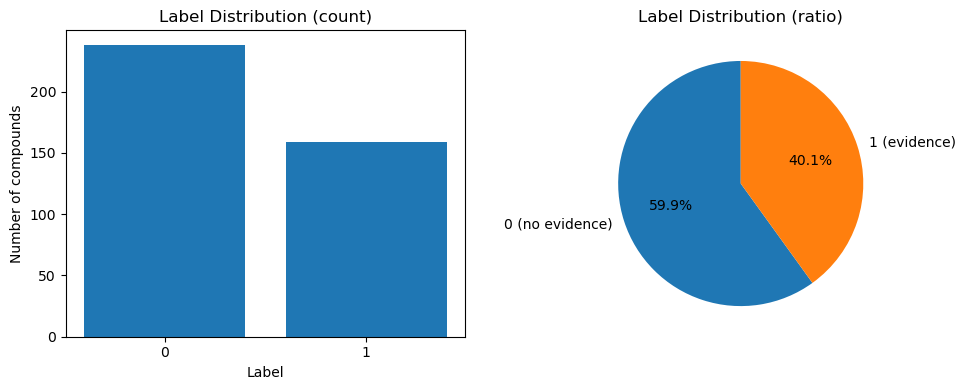

In [81]:
label_count = cancer_data["label"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1. 라벨별 화합물 개수를 보여주는 막대그래프(Bar chart)
axes[0].bar(["0", "1"], label_count)
axes[0].set_xlabel("Label")                  # x축 레이블 설정
axes[0].set_ylabel("Number of compounds")    # y축 레이블 설정
axes[0].set_title("Label Distribution (count)") # 그래프 제목 

# 2. 라벨별 비율을 나타내는 원그래프(Pie chart)
# autopct="%1.1f%%" -> 소수점 첫째 자리까지 비율 표시, startangle=90 -> 12시 방향부터 시작
axes[1].pie(label_count, labels=["0 (no evidence)", "1 (evidence)"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Label Distribution (ratio)") # 그래프 제목 

plt.tight_layout()
plt.show()

In [82]:
# descriptors 계산

# MolWt          : molecular weight
# MolLogP        : hydrophobicity (octanol-water partition coefficient)
# TPSA           : topological polar surface area
# RingCount      : number of rings
# NumHDonors     : number of hydrogen bond donors
# NumHAcceptors  : number of hydrogen bond acceptors
# NumRotatableBonds : molecular flexibility
# FractionCSP3   : fraction of sp3 carbons (3D-ness / saturation)
# NumAromaticRings  : number of aromatic rings
# HeavyAtomCount : number of non-hydrogen atoms (rough size)

descriptor_funcs = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "RingCount": Descriptors.RingCount,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
}

descriptor_columns = list(descriptor_funcs.keys())

for name, func in descriptor_funcs.items():
    cancer_data[name] = cancer_data["mol"].apply(func)

cancer_data[descriptor_columns].head()


,MolWt,MolLogP,TPSA,RingCount,NumHDonors,NumHAcceptors,NumRotatableBonds,FractionCSP3,NumAromaticRings,HeavyAtomCount
0,131.198,3.00880,0.00,1,0,0,1,0.000000,1,10
1,252.731,2.45470,0.00,0,0,0,0,1.000000,0,4
2,198.845,1.62588,23.79,0,0,1,0,0.500000,0,5
3,959.171,11.10390,9.23,2,0,1,2,0.000000,2,23
4,265.936,2.34236,47.58,0,0,2,3,0.666667,0,10


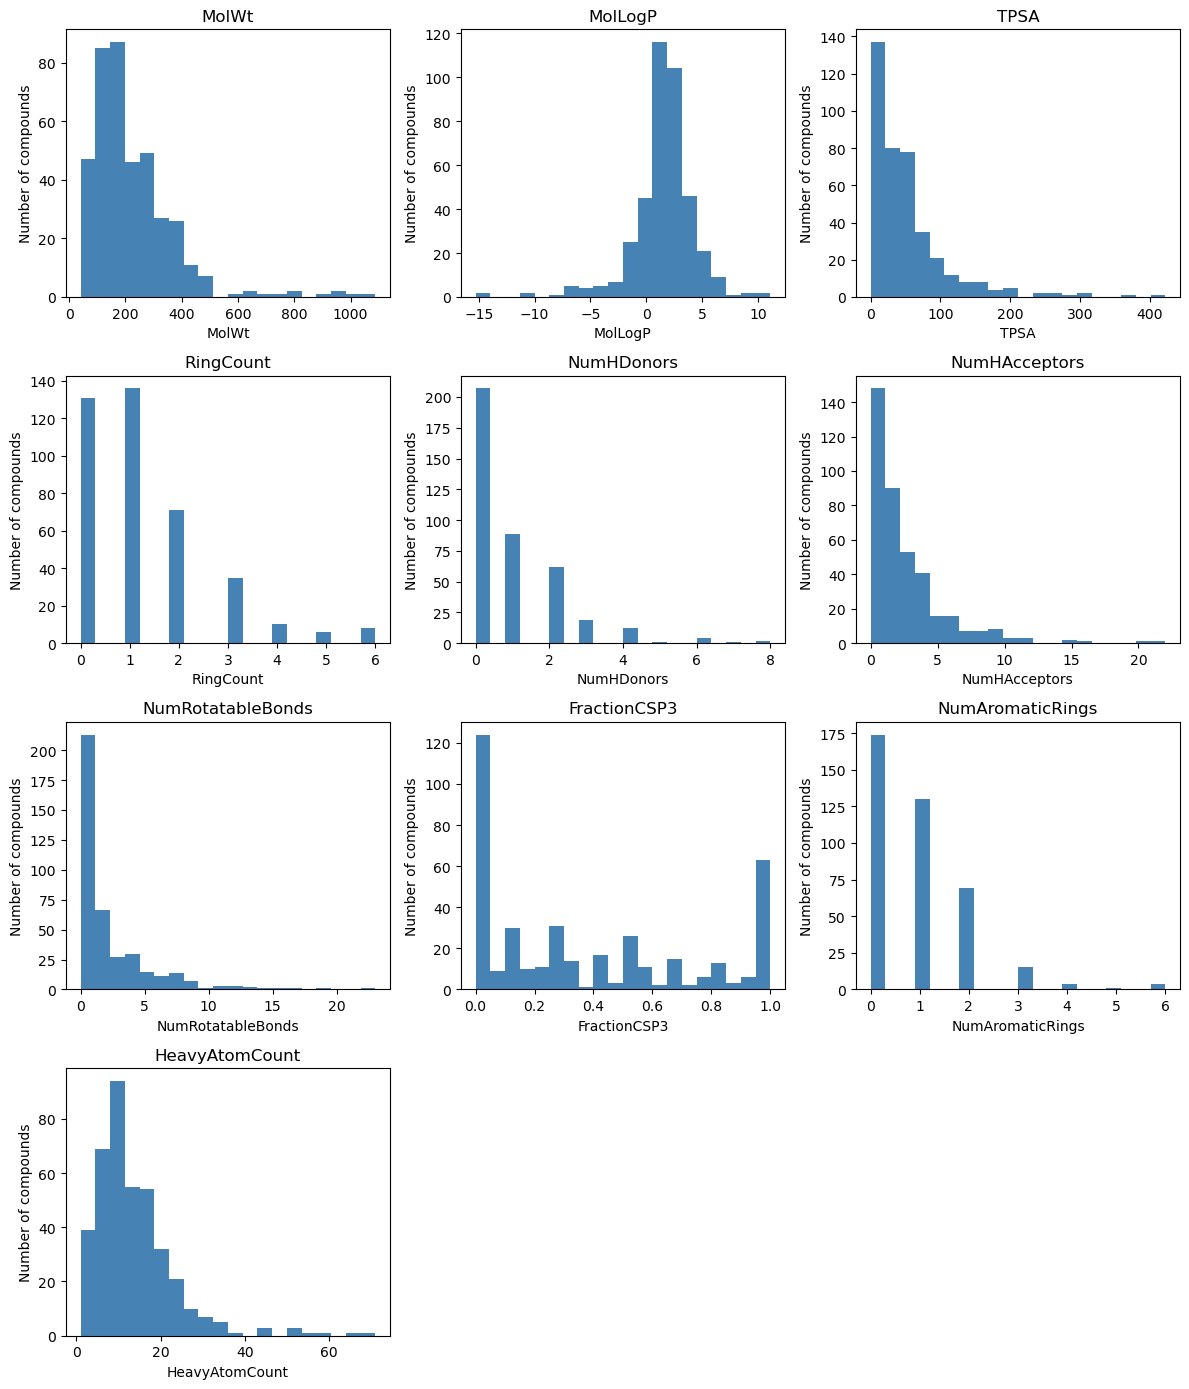

In [84]:
# descriptor 별 히스토그램
# 한 줄에 배치할 그래프 개수 설정
n_cols = 3
# 총 디스크립터 수에 맞게 필요한 서브플롯의 행(Row) 개수를 올림 연산으로 계산
n_rows = -(-len(descriptor_columns) // n_cols)  

# 전체 디스크립터를 시각화할 그리드 형태의 서브플롯 생성
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
# 반복문 순회를 위해 다차원 행렬 구조의 axes를 1차원 배열로 평탄화
axes = axes.flatten()

# 각 서브플롯 칸과 디스크립터 변수명을 매핑하여 히스토그램 생성
for ax, col in zip(axes, descriptor_columns):
    ax.hist(cancer_data[col], bins=20, color="steelblue") # 20개의 구간(bins)으로 히스토그램 그리기
    ax.set_title(col)                                     # 그래프 제목을 변수명으로 설정
    ax.set_xlabel(col)                                    # x축 레이블 설정
    ax.set_ylabel("Number of compounds")                  # y축 레이블 설정

# 데이터가 그려지지 않고 남은 빈 서브플롯 칸들은 화면에서 보이지 않도록 숨김 처리
for ax in axes[len(descriptor_columns):]:
    ax.axis("off")

# 그래프 간의 간격을 최적화하여 겹침을 방지하고 화면 출력
plt.tight_layout()
plt.show()

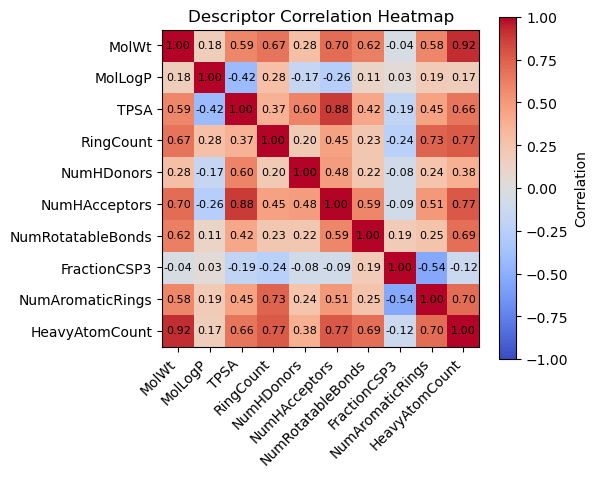

In [85]:
# 디스크립터 변수들 간의 피어슨 상관계수 행렬(Correlation Matrix) 계산
corr = cancer_data[descriptor_columns].corr()

# 히트맵을 그릴 단일 서브플롯 생성
fig, ax = plt.subplots(figsize=(6, 5))
# 상관계수 행렬을 이미지 형태로 시각화 (-1에서 1 범위를 coolwarm 색상축으로 표현)
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# x축과 y축에 디스크립터 변수 이름들을 라벨로 설정
ax.set_xticks(range(len(descriptor_columns)))
ax.set_xticklabels(descriptor_columns, rotation=45, ha="right")
ax.set_yticks(range(len(descriptor_columns)))
ax.set_yticklabels(descriptor_columns)

# 이중 루프를 통해 각 격자 칸에 해당하는 상관계수 값을 수치(소수점 둘째 자리)로 직접 표시
for i in range(len(descriptor_columns)):
    for j in range(len(descriptor_columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="black", fontsize=8)

# 그래프 오른쪽에 색상 기준 축(Colorbar)을 추가하고 제목 지정 후 화면 출력
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Descriptor Correlation Heatmap")
plt.tight_layout()
plt.show()

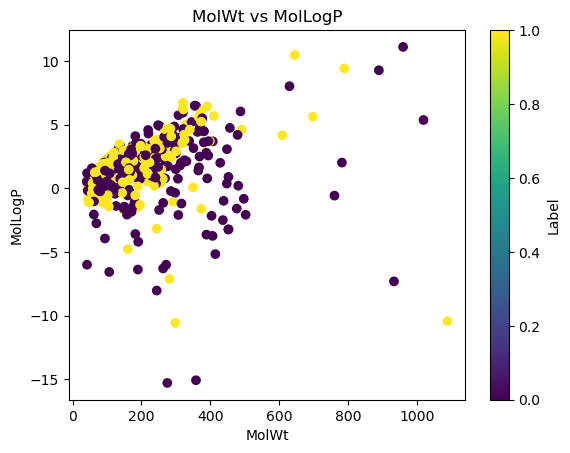

In [86]:
# 두 디스크립터(MolWt, MolLogP)의 상관관계 및 라벨별 분포를 확인하기 위한 산점도 생성
# MolWt, MolLogP: 분자의 체내 흡수율과 세포막 투과성을 결정하는 가장 대표적인 물리화학적 특성이기 때문에, 데이터의 대략적인 분포 패턴을 확인하는 기준 지표로 선정
# c=cancer_data["label"]을 통해 발암성 유무(0과 1)에 따라 점의 색상을 다르게 표현
plt.scatter(cancer_data["MolWt"], cancer_data["MolLogP"], c=cancer_data["label"])

# 각 축의 레이블 및 그래프 제목 설정
plt.xlabel("MolWt")
plt.ylabel("MolLogP")
plt.title("MolWt vs MolLogP")

# 데이터 값에 대응하는 색상 기준 축(Colorbar)을 추가하고 화면 출력
plt.colorbar(label="Label")
plt.show()

In [87]:
fingerprint_list = []

# 각 화합물의 분자 객체(mol)를 순회하며 Morgan Fingerprint 추출
for mol in cancer_data["mol"]:
    # 반지름(radius) 2 범위의 구조적 특징을 추출하여 128비트 크기의 이진 벡터로 표현
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=128)
    
    # 핑거프린트 데이터를 담을 크기 128의 빈 NumPy 배열 생성
    arr = np.zeros((128,), dtype=int)
    
    # 핑거프린트 객체(fp)의 데이터를 NumPy 배열(arr) 구조로 채워 넣음
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    # 변환이 완료된 배열을 리스트에 추가
    fingerprint_list.append(arr)

# 핑거프린트 리스트를 머신러닝 학습에 적합한 Pandas 데이터프레임 형태로 변환
fingerprint_data = pd.DataFrame(fingerprint_list)

# 생성된 핑거프린트 데이터셋의 크기(화합물 수 x 128개 변수) 확인
print(fingerprint_data.shape)

# 변환 결과를 시각적으로 검증하기 위해 상위 5개 행(0과 1로 구성된 데이터) 출력
fingerprint_data.head()

(397, 128)


[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerator
[15:50:45] DEPRECATION WARNING: please use MorganGenerat

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [88]:
from rdkit.Chem import MACCSkeys
# MACCS 키 데이터를 수치 벡터로 변환

maccs_list = []
# 각 화합물의 분자 객체(mol)를 순회하며 MACCS Key 추출
for mol in cancer_data["mol"]:
    # 분자 내 특정 화학적 구조 패턴(Substructure)의 존재 여부를 정의된 규칙에 따라 추출
    maccs_fp = MACCSkeys.GenMACCSKeys(mol)
    
    # 0번 인덱스를 포함하여 총 167비트 크기를 가지는 빈 NumPy 배열 생성
    arr = np.zeros((167,), dtype=int)
    
    # MACCS 키 데이터를 NumPy 배열 구조로 복사 및 변환
    DataStructs.ConvertToNumpyArray(maccs_fp, arr)
    
    maccs_list.append(arr)

# MACCS 키 리스트 -> Pandas 데이터프레임 형태로 변환
maccs_data = pd.DataFrame(maccs_list)

# 생성된 MACCS 데이터셋의 크기(화합물 수 x 167개 변수) 확인
print(maccs_data.shape)

maccs_data.head()

(397, 167)


,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,1,1,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


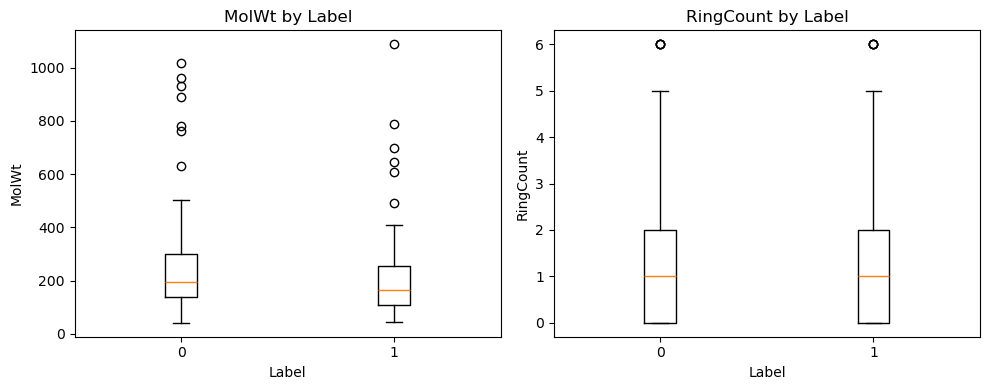

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 데이터를 타겟 라벨(0: 발암성 없음, 1: 발암성 있음) 기준으로 두 개의 그룹으로 분리
data_0 = cancer_data[cancer_data["label"] == 0]
data_1 = cancer_data[cancer_data["label"] == 1]

# 1. 라벨(0과 1)에 따른 분자량(MolWt)의 분포 차이
axes[0].boxplot([data_0["MolWt"], data_1["MolWt"]])
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["0", "1"])
axes[0].set_xlabel("Label")
axes[0].set_ylabel("MolWt")
axes[0].set_title("MolWt by Label")

# 2. 라벨(0과 1)에 따른 링 개수(RingCount)의 분포 차이
axes[1].boxplot([data_0["RingCount"], data_1["RingCount"]])
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["0", "1"])
axes[1].set_xlabel("Label")
axes[1].set_ylabel("RingCount")
axes[1].set_title("RingCount by Label")

plt.tight_layout()
plt.show()

In [90]:
# 1. Morgan 핑거프린트 데이터의 모든 열 이름을 'FP_0', 'FP_1'과 같은 형태로 변경
fingerprint_data.columns = [f"FP_{i}" for i in range(fingerprint_data.shape[1])]

# 2. MACCS 키 데이터의 모든 열 이름을 'MACCS_0', 'MACCS_1' 형태로 매핑하여 고유성 확보
maccs_data.columns = [f"MACCS_{i}" for i in range(maccs_data.shape[1])]

fingerprint_data.head()

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_118,FP_119,FP_120,FP_121,FP_122,FP_123,FP_124,FP_125,FP_126,FP_127
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [91]:
# 1. 병합 대상 열을 지정한 기본 정보 데이터 선택
basic_columns = ["Chemical_Name", "SMILES", "clean_smiles", "label"]
basic_data = cancer_data[basic_columns].reset_index(drop=True)

# 2. 병합 시 인덱스 불일치로 인한 데이터 누락을 방지하기 위해 모든 데이터프레임의 인덱스를 초기화
descriptor_data = cancer_data[descriptor_columns].reset_index(drop=True)
fingerprint_data = fingerprint_data.reset_index(drop=True)
maccs_data = maccs_data.reset_index(drop=True)

# 3. 분리되어 있던 기본 정보, 물리화학 디스크립터, 두 종류의 핑거프린트 데이터를 가로(열) 방향으로 통합
cancer_final = pd.concat(
    [basic_data, descriptor_data, fingerprint_data, maccs_data], axis=1
)

# 4. 2단계 머신러닝 학습 모델에 입력으로 사용할 최종 데이터셋을 CSV 파일로 저장
cancer_final.to_csv("final_dataset_descriptors.csv", index=False)

# 최종 데이터셋의 전체 크기(행과 특성 변수의 총 개수) 확인
print(cancer_final.shape)

cancer_final.head()

(397, 309)


,Chemical_Name,SMILES,clean_smiles,label,MolWt,MolLogP,TPSA,RingCount,NumHDonors,NumHAcceptors,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,Divinylbenzene,"*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|",*C=C.C=Cc1ccccc1,0.0,131.198,3.00880,0.00,1,0,0,...,0,0,0,0,0,1,1,0,1,1
1,Bromoform,BrC(Br)Br,BrC(Br)Br,0.0,252.731,2.45470,0.00,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Dibromoacetonitrile,BrC(Br)C#N,N#CC(Br)Br,1.0,198.845,1.62588,23.79,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3,"2,2',3,3',4,4',5,5',6,6'-Decabromodiphenyl ether",BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2...,Brc1c(Br)c(Br)c(Oc2c(Br)c(Br)c(Br)c(Br)c2Br)c(...,0.0,959.171,11.10390,9.23,2,0,1,...,1,0,0,0,0,1,1,1,1,0
4,"1,2-Dibromo-2,4-dicyanobutane",BrCC(Br)(CCC#N)C#N,N#CCCC(Br)(C#N)CBr,0.0,265.936,2.34236,47.58,0,0,2,...,0,0,0,0,1,0,0,0,0,0
